In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import gzip
import numpy as np

# Fragment Length Frequency

### 1. Read the BED Gzipped file
Decompress using gzip and obtain a DataFrame with 6 standard columns.

In [20]:
bed_cols = ['chrom', 'start_bp', 'end_bp', 'score', 'strand1', 'strand2']
bed_file = 'query.bed.gz'


with gzip.open(bed_file, 'rt') as gz:
    df = pd.read_csv(gz, sep='\t', names=bed_cols, header=None)

print(df.head())

df['frag_len'] = df['end_bp'] - df['start_bp']

# Get counts and normalize
frag_counts = df['frag_len'].value_counts().sort_index()
norm_counts = frag_counts / frag_counts.sum()

# Print some stats to verify
print(f"Total fragments: {len(df)}")
print(f"Fragment length range: {df['frag_len'].min()} to {df['frag_len'].max()} bp")


/var/folders/2z/89t0hm_55zqc0wx5y7lyhckw0000gn/T/ipykernel_51543/1275548853.py:6: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(gz, sep='\t', names=bed_cols, header=None)


   chrom  start_bp    end_bp score strand1 strand2
0  chr10  32795245  32795315    70       .       +
1  chr11  95864728  95864770    42       .       +
2  chr16  32027808  32027880    72       .       +
3   chr4  76608451  76608515    64       .       +
4  chr18  45847777  45847816    39       .       -
Total fragments: 13835737
Fragment length range: 24 to 700 bp


### 5. Plot the Fragment Length Distribution
Plot using a line plot for visual inspection.

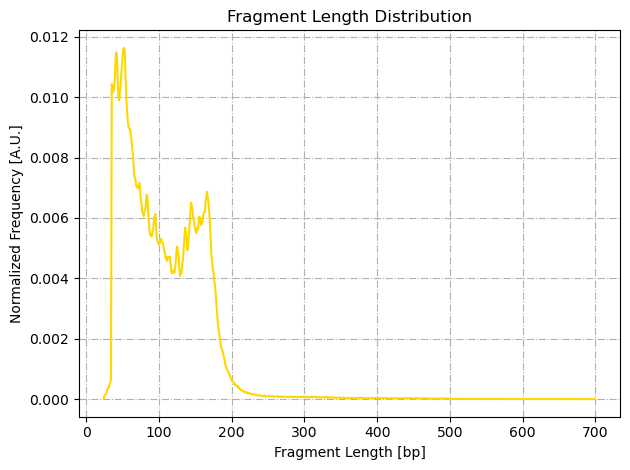

In [21]:
# plt.figure(figsize=(10,6))
plt.plot(norm_counts.index, norm_counts.values, color='gold')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')
plt.grid(True, linestyle='-.')
plt.tight_layout()
plt.show()

## Summary
Calculated fragment lengths and plotted normalized frequency.

# Rescaling Query Data to Match a Reference Distribution

### 1. Load the Reference Histogram
Read in the reference file with fragment lengths and frequencies.

In [22]:
ref_df = pd.read_csv('reference.hist', sep='\t', header=None, names=['frag_len', 'freq'])
print(ref_df.head())

   frag_len      freq
0        24  0.000013
1        25  0.000063
2        26  0.000092
3        27  0.000117
4        28  0.000136


### 2. Compute Target Fragment Counts
Adjust reference frequencies by total query read count.

In [23]:
total_reads = len(df)
ref_series = ref_df.set_index('frag_len')['freq']
target_counts = (ref_series * total_reads).round().astype(int) 

### 3. Subsample Query Data to Match Targets
For each fragment length, randomly sample fragments up to the target count.

In [24]:
grouped = df.groupby('frag_len')
samples = []
fixed_state = 42 #reproducibility
for flen, count_target in target_counts.items():
    if flen in grouped.groups:
        group_df = grouped.get_group(flen)
        n = min(count_target, len(group_df))
        if n > 0:
            samples.append(group_df.sample(n=n, random_state=fixed_state))
rescaled_df = pd.concat(samples, ignore_index=True)

### 4. Compare Rescaled Data with Reference
Plot the normalized frequency distributions for rescaled and reference.

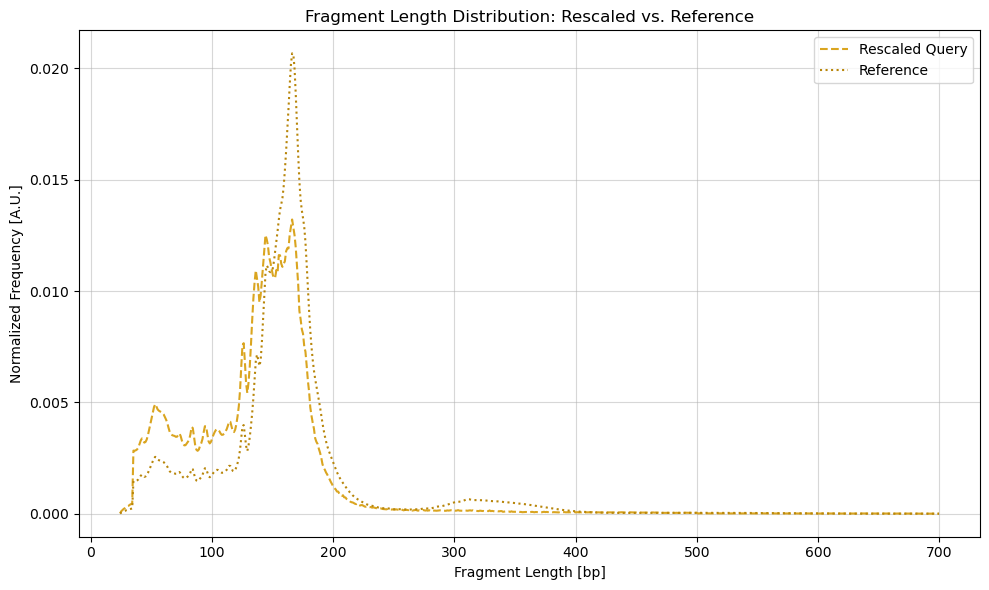

In [25]:
rescaled_counts = rescaled_df['frag_len'].value_counts().sort_index()
norm_rescaled = rescaled_counts / rescaled_counts.sum()

plt.figure(figsize=(10,6))
plt.plot(norm_rescaled.index, norm_rescaled.values, color='goldenrod', label='Rescaled Query', linestyle='--')
plt.plot(ref_df['frag_len'], ref_df['freq'], color='darkgoldenrod', label='Reference', linestyle=':')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution: Rescaled vs. Reference')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Summary
Subsampled query fragments are rescaled to match the reference distribution.